# Supply Chain Performance Dashboard
## Analyse Exploratoire des Données

Ce notebook réalise une exploration complète du dataset supply chain :
- Profiling des données
- Analyse des KPI globaux
- Performance des transporteurs
- Analyse géographique
- Tendances temporelles
- Analyse des retards

## 0. Configuration et imports

In [4]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Ajout du répertoire racine
sys.path.insert(0, str(Path().resolve().parent))

from src.config import OUTPUT_FILES
from src.utils import load_csv

# Style global
plt.rcParams.update({
    'figure.figsize':    (12, 5),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
})
sns.set_palette('Blues_r')
pd.set_option('display.float_format', '{:,.2f}'.format)

COLORS = {
    'primary':   '#2E86C1',
    'warning':   '#E67E22',
    'danger':    '#C0392B',
    'success':   '#27AE60',
    'neutral':   '#95A5A6',
}

print('Imports OK')

Imports OK


## 1. Chargement des données

In [16]:
# Chargement du dataset analytique enrichi
df = pd.read_csv(
    OUTPUT_FILES['analytics'],
    parse_dates=['order_date', 'expected_delivery_date', 'actual_delivery_date'],
    low_memory=False
)

carriers   = load_csv(OUTPUT_FILES['carriers_raw'])
warehouses = load_csv(OUTPUT_FILES['warehouses_raw'])

print(f'Dataset shape: {df.shape}')
print(f'Period: {df["order_date"].min().date()} → {df["order_date"].max().date()}')
df.head(3)

[2026-03-08 11:25:46] INFO     utils — Loaded carriers.csv: 12 rows × 4 cols
[2026-03-08 11:25:46] INFO     utils — Loaded warehouses.csv: 18 rows × 5 cols


Dataset shape: (50000, 43)
Period: 2022-01-01 → 2024-12-30


,order_id,customer_id,carrier_id,warehouse_id,order_date_key,expected_date_key,actual_date_key,order_date,expected_delivery_date,actual_delivery_date,...,city,warehouse_region,warehouse_country,main_product_id,main_category,main_subcategory,is_on_time,is_critical,is_high_value,delay_bucket
0,ORD029510,CUST00788,CAR004,WH-CHICAGO,20220101,20220117,20220117,2022-01-01,2022-01-17,2022-01-17,...,Chicago,North America,USA,PRD0200,Office,Furniture,1,0,0,On Time
1,ORD039261,CUST00337,CAR009,WH-MILAN,20220101,20220108,20220108,2022-01-01,2022-01-08,2022-01-08,...,Milan,Europe,Italy,PRD0220,Office,Stationery,1,1,1,On Time
2,ORD019123,CUST00347,CAR004,WH-MADRID,20220101,20220121,20220121,2022-01-01,2022-01-21,2022-01-21,...,Madrid,Europe,Spain,PRD0121,Fashion,Footwear,1,0,0,On Time


## 2. Profiling rapide

In [17]:
print('=== Data Types & Missing Values ===')
info = pd.DataFrame({
    'dtype':   df.dtypes,
    'n_null':  df.isnull().sum(),
    'pct_null': (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique(),
})
info[info['n_null'] > 0]

=== Data Types & Missing Values ===


,dtype,n_null,pct_null,n_unique
carrier_id,str,1434,2.87,12
carrier_name,str,1434,2.87,12
carrier_type,str,1434,2.87,4
service_level,str,1434,2.87,3


In [18]:
print('=== Numeric Summary ===')
df[['order_value', 'shipping_cost', 'delay_days', 'lead_time_days', 'shipping_cost_ratio']].describe().round(2)

=== Numeric Summary ===


,order_value,shipping_cost,delay_days,lead_time_days,shipping_cost_ratio
count,"50,000.00","50,000.00","50,000.00","50,000.00","50,000.00"
mean,"3,642.96",288.89,1.72,13.23,0.09
std,"5,575.27",435.37,4.45,6.85,0.17
min,16.78,0.60,-2.00,1.00,0.00
25%,811.77,60.35,0.00,8.00,0.05
50%,"1,806.82",138.00,0.00,13.00,0.08
75%,"4,044.54",311.26,0.00,18.00,0.12
max,"50,000.00","2,681.69",19.00,39.00,19.01


## 3. KPI Globaux

In [7]:
kpi = {
    'Total Orders':           len(df),
    'Total Revenue (€)':      df['order_value'].sum(),
    'Total Shipping Cost (€)':df['shipping_cost'].sum(),
    'Avg Order Value (€)':    df['order_value'].mean(),
    'Avg Lead Time (days)':   df['lead_time_days'].mean(),
    'On-Time Rate (%)':       (df['is_late'] == 0).mean() * 100,
    'Late Rate (%)':          df['is_late'].mean() * 100,
    'Avg Delay When Late (d)':df.loc[df['is_late']==1, 'delay_days'].mean(),
    'Shipping Ratio (%)':     (df['shipping_cost'] / df['order_value']).mean() * 100,
}

print('\n  === SUPPLY CHAIN KPI SUMMARY ===')
for k, v in kpi.items():
    if 'Orders' in k:
        print(f'  {k:<30} {int(v):>12,}')
    elif '%' in k:
        print(f'  {k:<30} {v:>11.2f}%')
    else:
        print(f'  {k:<30} {v:>12,.2f}')


  === SUPPLY CHAIN KPI SUMMARY ===
  Total Orders                         50,000
  Total Revenue (€)              182,148,009.37
  Total Shipping Cost (€)        14,444,648.04
  Avg Order Value (€)                3,642.96
  Avg Lead Time (days)                  13.23
  On-Time Rate (%)                     79.72%
  Late Rate (%)                        20.28%
  Avg Delay When Late (d)                8.83
  Shipping Ratio (%)                    9.15%


## 4. Distribution des statuts et priorités

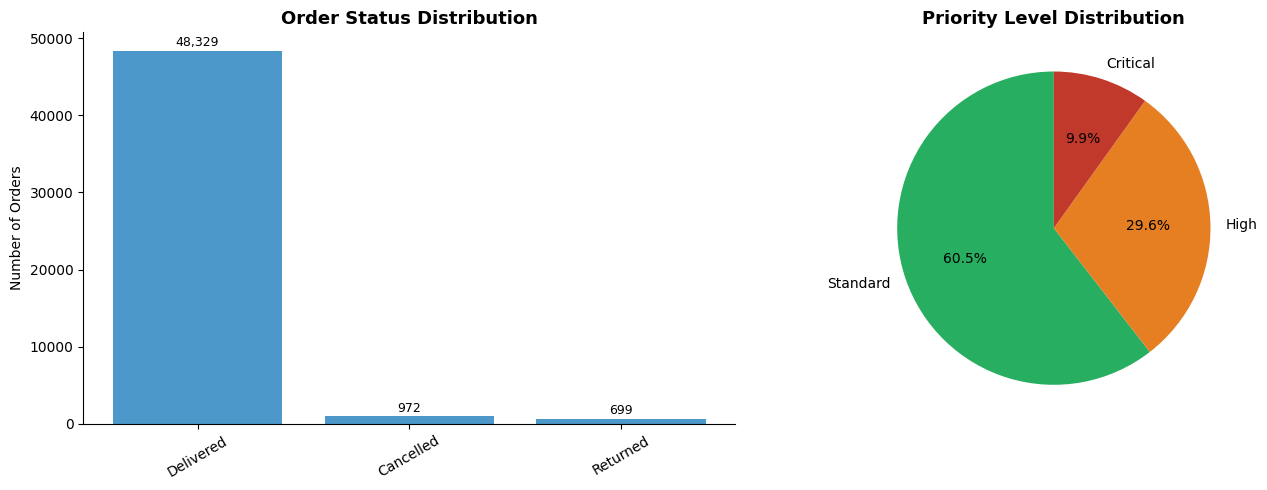

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Statuts
status_counts = df['order_status'].value_counts()
axes[0].bar(status_counts.index, status_counts.values, color=COLORS['primary'], alpha=0.85)
axes[0].set_title('Order Status Distribution')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[0].patches, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Priorités
prio_counts = df['priority_level'].value_counts()
colors_prio = [COLORS['success'], COLORS['warning'], COLORS['danger']]
axes[1].pie(prio_counts.values, labels=prio_counts.index, autopct='%1.1f%%',
            colors=colors_prio, startangle=90)
axes[1].set_title('Priority Level Distribution')

plt.tight_layout()
plt.show()

## 5. Tendances mensuelles

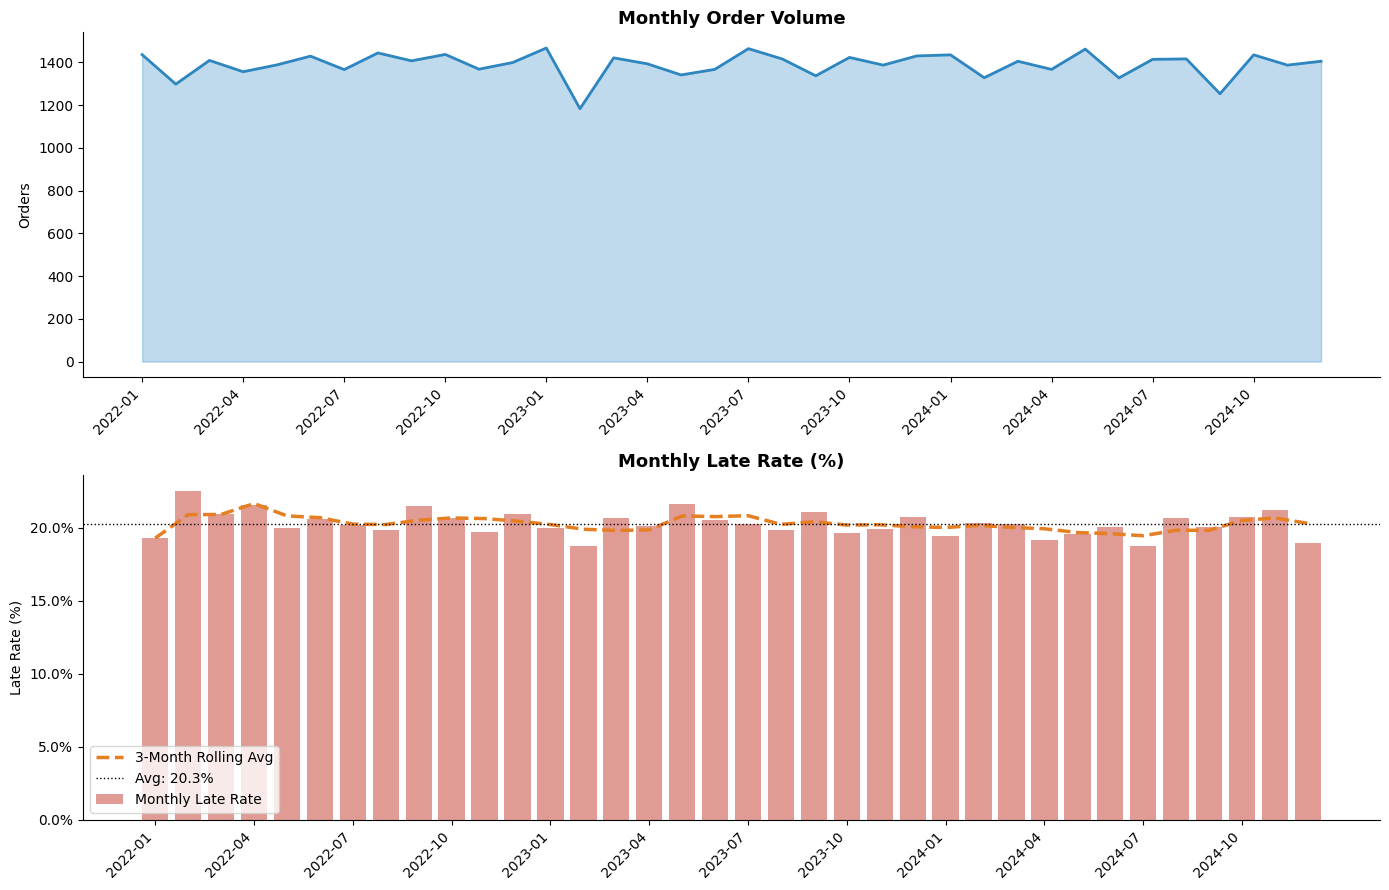

In [9]:
monthly = df.groupby('order_year_month').agg(
    total_orders  = ('order_id',       'count'),
    late_orders   = ('is_late',        'sum'),
    total_revenue = ('order_value',    'sum'),
    avg_lead_time = ('lead_time_days', 'mean'),
).reset_index()
monthly['late_rate_pct'] = monthly['late_orders'] / monthly['total_orders'] * 100
monthly['rolling_late']  = monthly['late_rate_pct'].rolling(3, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Volume mensuel
x = range(len(monthly))
axes[0].fill_between(x, monthly['total_orders'], alpha=0.3, color=COLORS['primary'])
axes[0].plot(x, monthly['total_orders'], color=COLORS['primary'], linewidth=2)
axes[0].set_title('Monthly Order Volume')
axes[0].set_ylabel('Orders')
axes[0].set_xticks(x[::3])
axes[0].set_xticklabels(monthly['order_year_month'].iloc[::3], rotation=45, ha='right')

# Taux de retard mensuel
axes[1].bar(x, monthly['late_rate_pct'], alpha=0.5, color=COLORS['danger'], label='Monthly Late Rate')
axes[1].plot(x, monthly['rolling_late'], color=COLORS['warning'], linewidth=2.5,
             linestyle='--', label='3-Month Rolling Avg')
axes[1].axhline(monthly['late_rate_pct'].mean(), color='black', linewidth=1,
                linestyle=':', label=f'Avg: {monthly["late_rate_pct"].mean():.1f}%')
axes[1].set_title('Monthly Late Rate (%)')
axes[1].set_ylabel('Late Rate (%)')
axes[1].set_xticks(x[::3])
axes[1].set_xticklabels(monthly['order_year_month'].iloc[::3], rotation=45, ha='right')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

## 6. Performance des transporteurs

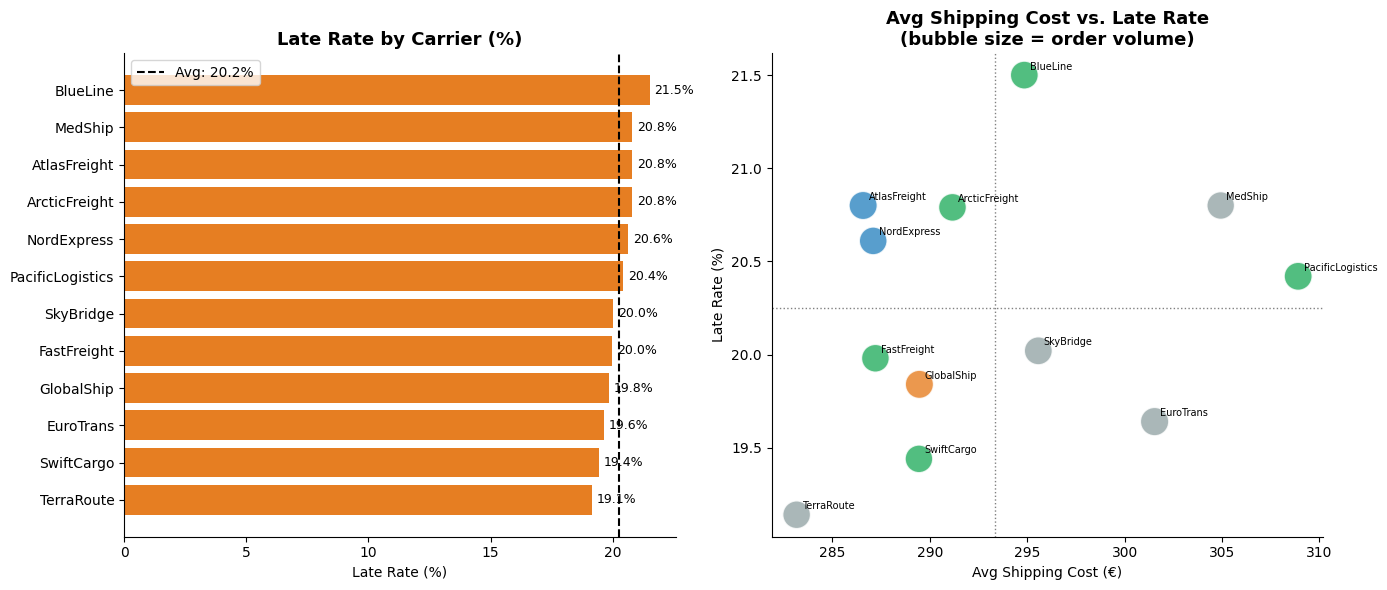


Top 3 performers (lowest late rate):
carrier_name  late_rate_pct  avg_lead_time  avg_shipping
  TerraRoute          19.14          13.14        283.16
  SwiftCargo          19.44          12.99        289.44
   EuroTrans          19.64          13.05        301.54

Worst 3 performers:
carrier_name  late_rate_pct  avg_lead_time  avg_shipping
AtlasFreight          20.80          13.22        286.58
     MedShip          20.80          13.19        304.93
    BlueLine          21.50          13.40        294.85


In [10]:
carrier_kpi = df.groupby('carrier_id').agg(
    total_orders    = ('order_id',       'count'),
    late_orders     = ('is_late',        'sum'),
    avg_lead_time   = ('lead_time_days', 'mean'),
    avg_delay       = ('delay_days',     'mean'),
    avg_shipping    = ('shipping_cost',  'mean'),
).reset_index()
carrier_kpi['late_rate_pct'] = (carrier_kpi['late_orders'] / carrier_kpi['total_orders'] * 100).round(2)
carrier_kpi = carrier_kpi.merge(carriers[['carrier_id', 'carrier_name', 'carrier_type']], on='carrier_id')
carrier_kpi = carrier_kpi.sort_values('late_rate_pct')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Taux de retard par transporteur
bar_colors = [COLORS['success'] if r < 15 else COLORS['warning'] if r < 22 else COLORS['danger']
              for r in carrier_kpi['late_rate_pct']]
axes[0].barh(carrier_kpi['carrier_name'], carrier_kpi['late_rate_pct'], color=bar_colors)
axes[0].axvline(carrier_kpi['late_rate_pct'].mean(), color='black', linestyle='--', linewidth=1.5,
                label=f'Avg: {carrier_kpi["late_rate_pct"].mean():.1f}%')
axes[0].set_title('Late Rate by Carrier (%)')
axes[0].set_xlabel('Late Rate (%)')
axes[0].legend()
for i, (val, name) in enumerate(zip(carrier_kpi['late_rate_pct'], carrier_kpi['carrier_name'])):
    axes[0].text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=9)

# Scatter coût vs. taux de retard
scatter_colors = [COLORS['success'] if t == 'Air' else
                  COLORS['primary'] if t == 'Ground' else
                  COLORS['warning'] if t == 'Sea' else COLORS['neutral']
                  for t in carrier_kpi['carrier_type']]
sc = axes[1].scatter(
    carrier_kpi['avg_shipping'], carrier_kpi['late_rate_pct'],
    s=carrier_kpi['total_orders'] / 10, c=scatter_colors, alpha=0.8, edgecolors='white'
)
axes[1].axvline(carrier_kpi['avg_shipping'].mean(), color='grey', linestyle=':', linewidth=1)
axes[1].axhline(carrier_kpi['late_rate_pct'].mean(), color='grey', linestyle=':', linewidth=1)
for _, row in carrier_kpi.iterrows():
    axes[1].annotate(row['carrier_name'], (row['avg_shipping'], row['late_rate_pct']),
                     fontsize=7, xytext=(4, 4), textcoords='offset points')
axes[1].set_title('Avg Shipping Cost vs. Late Rate\n(bubble size = order volume)')
axes[1].set_xlabel('Avg Shipping Cost (€)')
axes[1].set_ylabel('Late Rate (%)')

plt.tight_layout()
plt.show()

print('\nTop 3 performers (lowest late rate):')
print(carrier_kpi[['carrier_name', 'late_rate_pct', 'avg_lead_time', 'avg_shipping']].head(3).to_string(index=False))
print('\nWorst 3 performers:')
print(carrier_kpi[['carrier_name', 'late_rate_pct', 'avg_lead_time', 'avg_shipping']].tail(3).to_string(index=False))

## 7. Analyse géographique

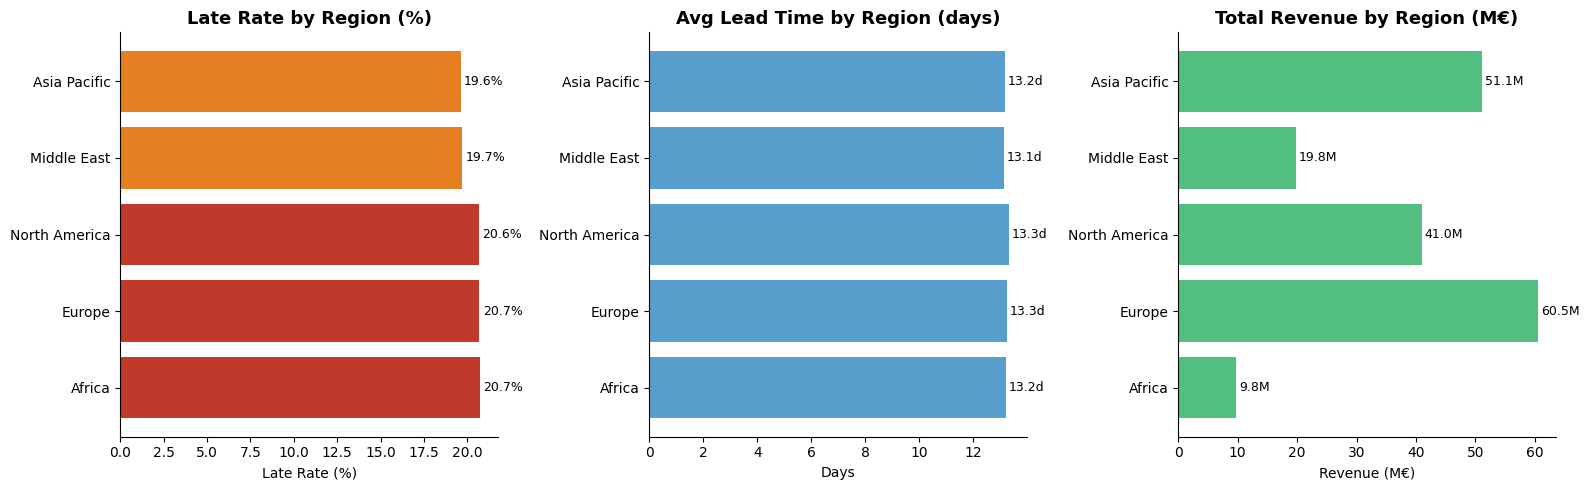

In [11]:
region_kpi = df.groupby('region').agg(
    total_orders  = ('order_id',       'count'),
    late_orders   = ('is_late',        'sum'),
    avg_lead_time = ('lead_time_days', 'mean'),
    avg_shipping  = ('shipping_cost',  'mean'),
    total_revenue = ('order_value',    'sum'),
).reset_index()
region_kpi['late_rate_pct'] = (region_kpi['late_orders'] / region_kpi['total_orders'] * 100).round(2)
region_kpi = region_kpi.sort_values('late_rate_pct', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].barh(region_kpi['region'], region_kpi['late_rate_pct'],
             color=[COLORS['danger'] if r > 20 else COLORS['warning'] if r > 15 else COLORS['success']
                    for r in region_kpi['late_rate_pct']])
axes[0].set_title('Late Rate by Region (%)')
axes[0].set_xlabel('Late Rate (%)')
for i, v in enumerate(region_kpi['late_rate_pct']):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

axes[1].barh(region_kpi['region'], region_kpi['avg_lead_time'], color=COLORS['primary'], alpha=0.8)
axes[1].set_title('Avg Lead Time by Region (days)')
axes[1].set_xlabel('Days')
for i, v in enumerate(region_kpi['avg_lead_time']):
    axes[1].text(v + 0.1, i, f'{v:.1f}d', va='center', fontsize=9)

axes[2].barh(region_kpi['region'], region_kpi['total_revenue'] / 1e6, color=COLORS['success'], alpha=0.8)
axes[2].set_title('Total Revenue by Region (M€)')
axes[2].set_xlabel('Revenue (M€)')
for i, v in enumerate(region_kpi['total_revenue'] / 1e6):
    axes[2].text(v + 0.5, i, f'{v:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Distribution des retards

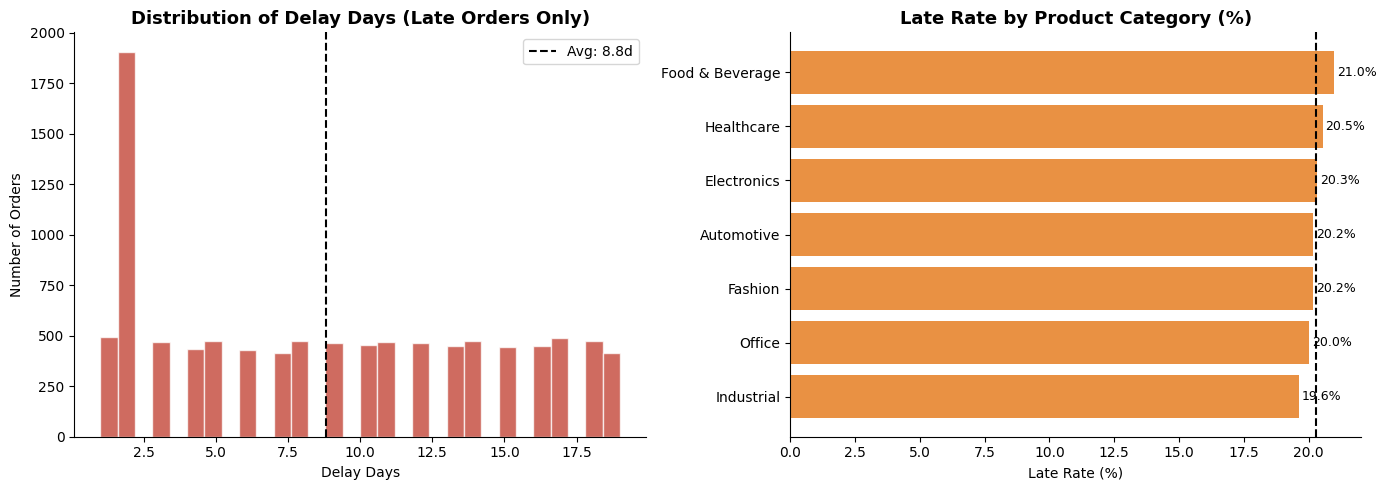

In [12]:
late_df = df[df['is_late'] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des jours de retard
axes[0].hist(late_df['delay_days'], bins=30, color=COLORS['danger'], alpha=0.75, edgecolor='white')
axes[0].axvline(late_df['delay_days'].mean(), color='black', linestyle='--', linewidth=1.5,
                label=f'Avg: {late_df["delay_days"].mean():.1f}d')
axes[0].set_title('Distribution of Delay Days (Late Orders Only)')
axes[0].set_xlabel('Delay Days')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

# Retards par catégorie
if 'main_category' in df.columns:
    cat_kpi = df.dropna(subset=['main_category']).groupby('main_category').agg(
        total = ('order_id', 'count'),
        late  = ('is_late',  'sum'),
    ).reset_index()
    cat_kpi['late_rate'] = cat_kpi['late'] / cat_kpi['total'] * 100
    cat_kpi = cat_kpi.sort_values('late_rate', ascending=True)
    
    axes[1].barh(cat_kpi['main_category'], cat_kpi['late_rate'],
                 color=COLORS['warning'], alpha=0.85)
    axes[1].axvline(cat_kpi['late_rate'].mean(), color='black', linestyle='--', linewidth=1.5)
    axes[1].set_title('Late Rate by Product Category (%)')
    axes[1].set_xlabel('Late Rate (%)')
    for i, v in enumerate(cat_kpi['late_rate']):
        axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Heatmap entrepôts × mois

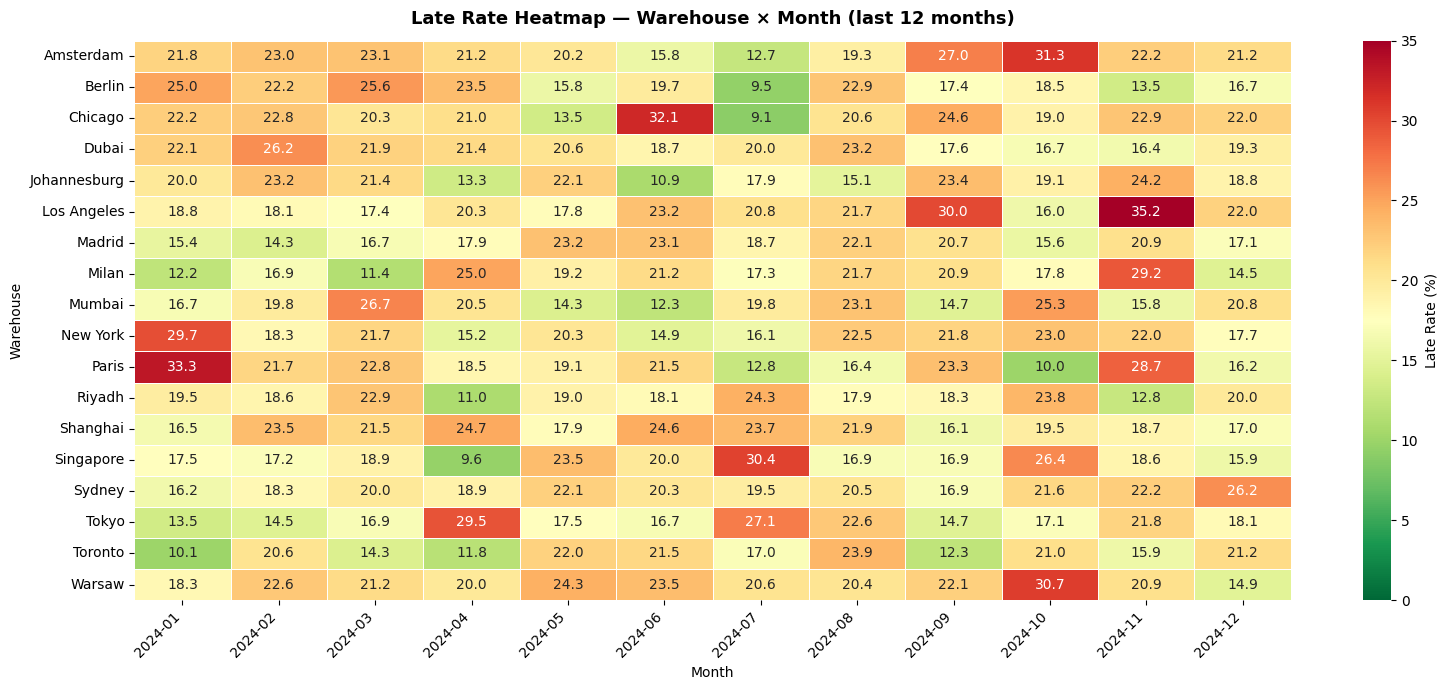

In [13]:
wh_monthly = df.groupby(['warehouse_id', 'order_year_month']).agg(
    total = ('order_id', 'count'),
    late  = ('is_late',  'sum'),
).reset_index()
wh_monthly['late_rate'] = wh_monthly['late'] / wh_monthly['total'] * 100

wh_monthly = wh_monthly.merge(
    warehouses[['warehouse_id', 'warehouse_name']], on='warehouse_id'
)

# Pivot pour heatmap (6 derniers mois pour lisibilité)
last_months = sorted(wh_monthly['order_year_month'].unique())[-12:]
pivot = wh_monthly[wh_monthly['order_year_month'].isin(last_months)].pivot_table(
    index='warehouse_name', columns='order_year_month', values='late_rate'
).round(1)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Late Rate (%)'},
    vmin=0, vmax=35
)
ax.set_title('Late Rate Heatmap — Warehouse × Month (last 12 months)', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Warehouse')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Analyse financière

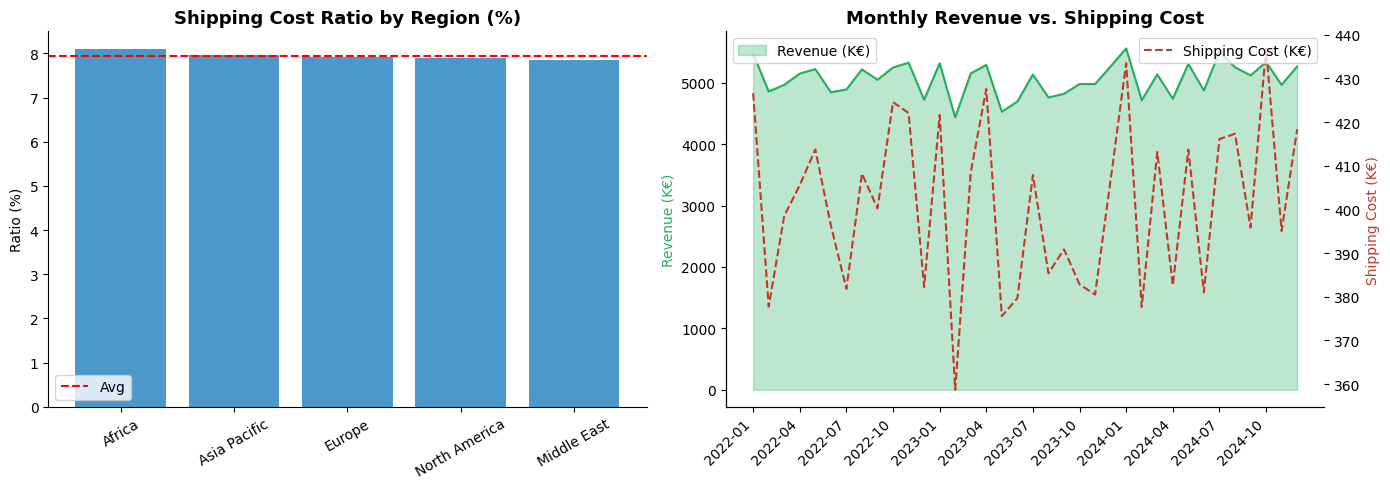

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ratio coût logistique par région
ratio_region = df.groupby('region').apply(
    lambda g: (g['shipping_cost'].sum() / g['order_value'].sum() * 100)
).reset_index()
ratio_region.columns = ['region', 'shipping_ratio_pct']
ratio_region = ratio_region.sort_values('shipping_ratio_pct', ascending=False)

axes[0].bar(ratio_region['region'], ratio_region['shipping_ratio_pct'],
            color=COLORS['primary'], alpha=0.85)
axes[0].axhline(ratio_region['shipping_ratio_pct'].mean(), color='red',
                linestyle='--', linewidth=1.5, label='Avg')
axes[0].set_title('Shipping Cost Ratio by Region (%)')
axes[0].set_ylabel('Ratio (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# Évolution mensuelle CA vs. coûts logistiques
monthly_fin = df.groupby('order_year_month').agg(
    revenue  = ('order_value',   'sum'),
    shipping = ('shipping_cost', 'sum'),
).reset_index()
x = range(len(monthly_fin))
ax2 = axes[1].twinx()
axes[1].fill_between(x, monthly_fin['revenue'] / 1000, alpha=0.3, color=COLORS['success'],
                     label='Revenue (K€)')
axes[1].plot(x, monthly_fin['revenue'] / 1000, color=COLORS['success'], linewidth=1.5)
ax2.plot(x, monthly_fin['shipping'] / 1000, color=COLORS['danger'],
         linewidth=1.5, linestyle='--', label='Shipping Cost (K€)')
axes[1].set_title('Monthly Revenue vs. Shipping Cost')
axes[1].set_ylabel('Revenue (K€)', color=COLORS['success'])
ax2.set_ylabel('Shipping Cost (K€)', color=COLORS['danger'])
xtick_positions = list(range(0, len(monthly_fin), 3))
axes[1].set_xticks(xtick_positions)
axes[1].set_xticklabels(monthly_fin['order_year_month'].iloc[xtick_positions], rotation=45, ha='right')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 11. Synthèse des insights

In [15]:
print('\n' + '='*60)
print('  TOP INSIGHTS — SUPPLY CHAIN ANALYSIS')
print('='*60)

on_time_rate = (df['is_late'] == 0).mean() * 100
late_rate    = df['is_late'].mean() * 100
best_carrier = carrier_kpi.iloc[0]['carrier_name'] if len(carrier_kpi) > 0 else 'N/A'
worst_carrier= carrier_kpi.iloc[-1]['carrier_name'] if len(carrier_kpi) > 0 else 'N/A'
worst_region = region_kpi.iloc[0]['region']
avg_delay    = df.loc[df['is_late']==1, 'delay_days'].mean()
late_revenue = df.loc[df['is_late']==1, 'order_value'].sum()
total_revenue= df['order_value'].sum()

print(f'\n  1. On-Time Delivery Rate  : {on_time_rate:.1f}% (target: >85%)')
print(f'  2. Overall Late Rate      : {late_rate:.1f}% of orders')
print(f'  3. Best carrier           : {best_carrier}')
print(f'  4. Worst carrier          : {worst_carrier}')
print(f'  5. Highest risk region    : {worst_region}')
print(f'  6. Avg delay (late orders): {avg_delay:.1f} days')
print(f'  7. Revenue at risk        : €{late_revenue:,.0f} ({late_revenue/total_revenue*100:.1f}% of total CA)')
print('='*60)
print('\n  Full insights: see docs/insights.md')


  TOP INSIGHTS — SUPPLY CHAIN ANALYSIS

  1. On-Time Delivery Rate  : 79.7% (target: >85%)
  2. Overall Late Rate      : 20.3% of orders
  3. Best carrier           : TerraRoute
  4. Worst carrier          : BlueLine
  5. Highest risk region    : Africa
  6. Avg delay (late orders): 8.8 days
  7. Revenue at risk        : €36,764,572 (20.2% of total CA)

  Full insights: see docs/insights.md
